In [ ]:
import os
import cv2
import numpy as np
import librosa
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import librosa
from tensorflow.keras.preprocessing.sequence import pad_sequences

def extract_frames(video_path, num_frames=30):
    try:
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_interval = max(total_frames // num_frames, 1)

        for i in range(num_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, (224, 224))
                frames.append(frame)
            else:
                break

        cap.release()
        if len(frames) == 0:
            raise ValueError("No frames extracted")
        return np.array(frames)
    except Exception as e:
        print(f"Error extracting frames from {video_path}: {e}")
        return None

def extract_audio_features(audio_path, n_mfcc=40, max_pad_len=862):
    try:
        y, sr = librosa.load(audio_path, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
        return mfcc.T
    except Exception as e:
        print(f"Error extracting audio features from {audio_path}: {e}")
        return None

# Paths to dataset
DATASET_PATH = '/content/drive/MyDrive/Emotion Dataset/Video/split_video/test'
CLASS_NAMES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

video_data = []
audio_data = []
labels = []

for class_name in CLASS_NAMES:
    class_path = os.path.join(DATASET_PATH, class_name)
    for video_name in os.listdir(class_path):
        video_path = os.path.join(class_path, video_name)
        if not video_name.endswith('.mp4'):
            continue
        frames = extract_frames(video_path)
        audio_features = extract_audio_features(video_path)

        if frames is not None and audio_features is not None:
            video_data.append(frames)
            audio_data.append(audio_features)
            labels.append(CLASS_NAMES.index(class_name))
        else:
            print(f"Skipping {video_name} due to insufficient data")

# Pad video sequences to a uniform length
video_data_padded = pad_sequences(video_data, padding='post', dtype='float32')

audio_data = pad_sequences(audio_data, padding='post', dtype='float32')  # Pad sequences to the same length
labels = np.array(labels)

print("Video data shape:", video_data_padded.shape) # Use the padded video data
print("Audio data shape:", audio_data.shape)
print("Labels shape:", labels.shape)


<ipython-input-3-695db433ae1c>:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-3-695db433ae1c>:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-3-695db433ae1c>:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/

Video data shape: (311, 30, 224, 224, 3)
Audio data shape: (311, 862, 40)
Labels shape: (311,)


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import tensorflow as tf

# Load pre-trained MobileNetV2 model + higher level layers
base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
video_model = Model(inputs=base_model.input, outputs=x)

# Extract features from each frame set
video_features = []
for frames in video_data:
    features = video_model.predict(frames)
    video_features.append(features.mean(axis=0))  # Average features over frames

video_features = np.array(video_features)
print("Video features shape:", video_features.shape)




from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import tensorflow as tf

# Load pre-trained VGG16 model + higher level layers
base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
video_model = Model(inputs=base_model.input, outputs=x)

# Extract features from each frame set
video_features = []
for frames in video_data:
    features = video_model.predict(frames)
    video_features.append(features.mean(axis=0))  # Average features over frames

video_features = np.array(video_features)
print("Video features shape:", video_features.shape)



1/1 [==============================] - 0s 29ms/step
Video features shape: (311, 512)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_video, X_test_video, X_train_audio, X_test_audio, y_train, y_test = train_test_split(
    video_features, audio_data, labels, test_size=0.3, random_state=42)

# Ensure audio data shape compatibility
X_train_audio = np.expand_dims(X_train_audio, -1)
X_test_audio = np.expand_dims(X_test_audio, -1)

print("Train video shape:", X_train_video.shape)
print("Test video shape:", X_test_video.shape)
print("Train audio shape:", X_train_audio.shape)
print("Test audio shape:", X_test_audio.shape)
print("Train labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Train video shape: (217, 512)
Test video shape: (94, 512)
Train audio shape: (217, 862, 40, 1)
Test audio shape: (94, 862, 40, 1)
Train labels shape: (217,)
Test labels shape: (94,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, concatenate, Dropout
from tensorflow.keras.regularizers import l2

video_input = Input(shape=(512,))  # Adjust input shape to match actual video feature dimensions
video_dense = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(video_input)
video_dropout = Dropout(0.5)(video_dense)

# Audio model
audio_input = Input(shape=(862, 40))
audio_lstm = LSTM(128, kernel_regularizer=l2(0.001))(audio_input)
audio_dropout = Dropout(0.5)(audio_lstm)

# Fusion model
merged = concatenate([video_dropout, audio_dropout])
dense_1 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(merged)
dense_1_dropout = Dropout(0.5)(dense_1)
output = Dense(len(CLASS_NAMES), activation='softmax')(dense_1_dropout)

fusion_model = Model(inputs=[video_input, audio_input], outputs=output)
fusion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fusion_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 512)]                0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 862, 40)]            0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  65664     ['input_2[0][0]']             
                                                                                                  
 lstm (LSTM)                 (None, 128)                  86528     ['input_3[0][0]']             
                                                                                            

In [ ]:
history = fusion_model.fit(
    [X_train_video, X_train_audio], y_train,
    validation_data=([X_test_video, X_test_audio], y_test),
    epochs=50, batch_size=10)

Epoch 1/50
22/22 [==============================] - 1s 64ms/step - loss: 1.5282 - accuracy: 0.3963 - val_loss: 1.6381 - val_accuracy: 0.3404
Epoch 2/50
22/22 [==============================] - 1s 38ms/step - loss: 1.4532 - accuracy: 0.3779 - val_loss: 1.6230 - val_accuracy: 0.3404
Epoch 3/50
22/22 [==============================] - 1s 38ms/step - loss: 1.3733 - accuracy: 0.4147 - val_loss: 1.6006 - val_accuracy: 0.3511
Epoch 4/50
22/22 [==============================] - 1s 39ms/step - loss: 1.4014 - accuracy: 0.4194 - val_loss: 1.6114 - val_accuracy: 0.3298
Epoch 5/50
22/22 [==============================] - 1s 36ms/step - loss: 1.3693 - accuracy: 0.4194 - val_loss: 1.6101 - val_accuracy: 0.3298
Epoch 6/50
22/22 [==============================] - 1s 37ms/step - loss: 1.3634 - accuracy: 0.4240 - val_loss: 1.5985 - val_accuracy: 0.3404
Epoch 7/50
22/22 [==============================] - 1s 38ms/step - loss: 1.3626 - accuracy: 0.4332 - val_loss: 1.6058 - val_accuracy: 0.3085
Epoch 8/50
22

In [ ]:
# Generate classification report
from sklearn.metrics import classification_report
y_pred = np.argmax(fusion_model.predict([X_test_video, X_test_audio]), axis=1)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

3/3 [==============================] - 0s 25ms/step
              precision    recall  f1-score   support

       Angry       0.62      0.38      0.48        13
     Disgust       0.50      0.12      0.20        16
        Fear       0.35      0.46      0.40        13
       Happy       0.32      0.62      0.43        16
     Neutral       1.00      0.58      0.74        12
         Sad       0.22      0.33      0.27        12
    Surprise       0.44      0.33      0.38        12

    accuracy                           0.40        94
   macro avg       0.50      0.41      0.41        94
weighted avg       0.49      0.40      0.40        94



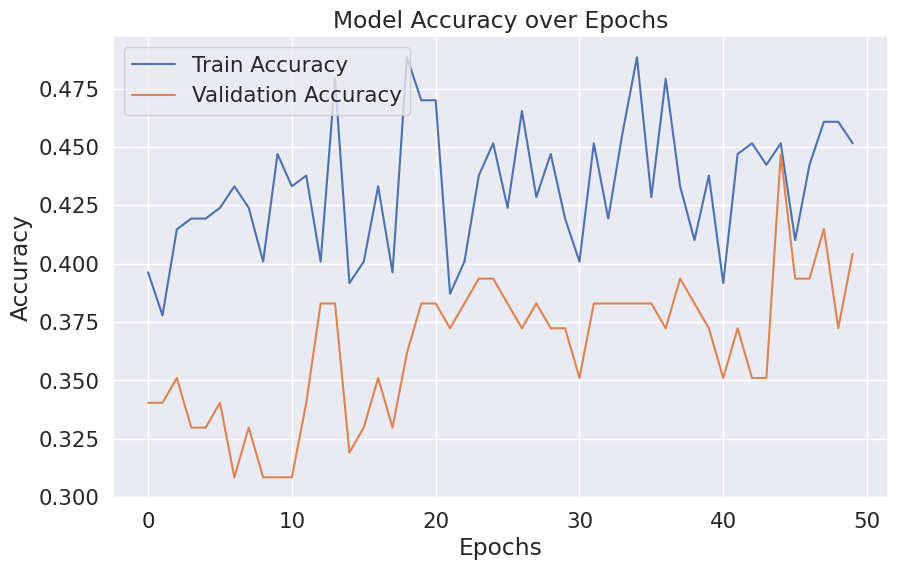

In [ ]:
import matplotlib.pyplot as plt

# Assuming `history` is the History object returned by model.fit()

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


In [ ]:


from sklearn.metrics import confusion_matrix

# Generate confusion matrix
confusion_matrix = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print(confusion_matrix)


[[ 5  0  1  4  0  3  0]
 [ 2  2  2  5  0  2  3]
 [ 0  1  6  4  0  1  1]
 [ 0  0  1 10  0  4  1]
 [ 0  0  3  0  7  2  0]
 [ 1  1  0  6  0  4  0]
 [ 0  0  4  2  0  2  4]]


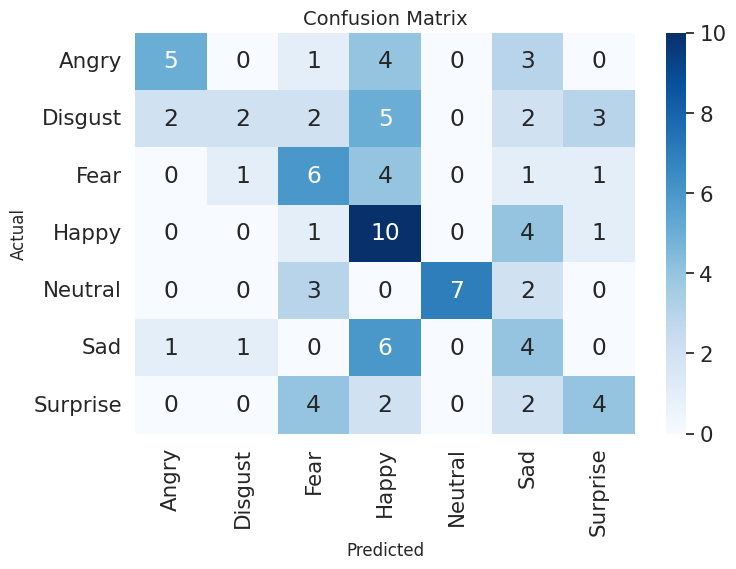

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix # Re-import the function

# Generate confusion matrix using the imported function
cm = confusion_matrix(y_test, y_pred)

# Set up the visualization
sns.set(font_scale=1.4)  # Increase font size
plt.figure(figsize=(8, 6))  # Set figure size

# Create the heatmap using cm
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)

# Add labels and title
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()  # Improve spacing

# Show the plot
plt.show()


In [ ]:
fusion_model.save('/content/drive/MyDrive/vggfusion.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
